## WHO Global Health Observatory Data import

In [2]:
import requests
import pandas as pd

who_url = "https://ghoapi.azureedge.net/api/IMR"
response = requests.get(who_url)
who_data = response.json()['value']

df_who = pd.DataFrame(who_data)
print(df_who.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14858 entries, 0 to 14857
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14858 non-null  int64  
 1   IndicatorCode       14858 non-null  object 
 2   SpatialDimType      14858 non-null  object 
 3   SpatialDim          14858 non-null  object 
 4   TimeDimType         14858 non-null  object 
 5   ParentLocationCode  14858 non-null  object 
 6   ParentLocation      14858 non-null  object 
 7   Dim1Type            14858 non-null  object 
 8   TimeDim             14858 non-null  int64  
 9   Dim1                14858 non-null  object 
 10  Dim2Type            0 non-null      object 
 11  Dim2                0 non-null      object 
 12  Dim3Type            0 non-null      object 
 13  Dim3                0 non-null      object 
 14  DataSourceDimType   14858 non-null  object 
 15  DataSourceDim       14858 non-null  object 
 16  Valu

In [9]:
df_who.to_csv(r"E:\My Files\Datasets\Infant mortality analysis\who_infant_mortality.csv", 
              index=False, encoding="utf-8")
print("File has been saved in the format of CSV.")

File has been saved in the format of CSV.


## Our World in Data (OWID)

In [11]:
import pandas as pd

owid_data = pd.read_csv("E:\My Files\Datasets\Infant mortality analysis\owid_infant_mortality.csv")

df_owid = pd.DataFrame(owid_data)
print(df_owid.info())
print(df_owid.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13577 entries, 0 to 13576
Data columns (total 4 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Entity                                                                    13577 non-null  object 
 1   Code                                                                      13001 non-null  object 
 2   Year                                                                      13577 non-null  int64  
 3   Infant mortality rate of babies aged under one year, per 100 live births  13577 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 424.4+ KB
None
        Entity Code  Year  \
0  Afghanistan  AFG  1957   
1  Afghanistan  AFG  1958   
2  Afghanistan  AFG  1959   
3  Afghanistan  AFG  1960   
4  Afghanistan  AFG  1961   

   Infant mortality rate of ba

## Merging Two Dataframes 

In [15]:
df_who_clean = df_who[['SpatialDim', 'TimeDim', 'NumericValue']]
df_who_clean.rename(columns = {
    'SpatialDim' : 'country_code',
    'TimeDim' : 'year',
    'NumericValue' : 'infant_mortality_rate'
}, inplace = True)
df_who_clean['source'] = 'WHO'

df_who_clean.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_9940\1322090019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_who_clean.rename(columns = {
C:\Users\hp\AppData\Local\Temp\ipykernel_9940\1322090019.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_who_clean['source'] = 'WHO'


,country_code,year,infant_mortality_rate,source
0,PER,2013,14.76560,WHO
1,NER,2012,17.51638,WHO
2,IDN,1994,67.99654,WHO
3,SOM,2006,96.16145,WHO
4,TCD,1996,73.27987,WHO


In [19]:
df_owid.rename(columns = {
    'Entity': 'country_name',
    'Code' : 'country_code',
    'Year' : 'year',
    'Infant mortality rate of babies aged under one year, per 100 live births' : 'infant_mortality_rate'
}, inplace = True)
df_owid['source'] = 'OWID'
df_owid.head()

,country_name,country_code,year,infant_mortality_rate,source
0,Afghanistan,AFG,1957,26.094225,OWID
1,Afghanistan,AFG,1958,25.776396,OWID
2,Afghanistan,AFG,1959,25.467907,OWID
3,Afghanistan,AFG,1960,25.123142,OWID
4,Afghanistan,AFG,1961,24.839281,OWID


In [18]:
code_to_name = df_owid.set_index('country_code')['country_name'].to_dict()
df_who_clean['country_name'] = df_who_clean['country_code'].map(code_to_name)
df_who_clean.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_9940\3530063799.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_who_clean['country_name'] = df_who_clean['country_code'].map(code_to_name)


,country_code,year,infant_mortality_rate,source,country_name
0,PER,2013,14.76560,WHO,Peru
1,NER,2012,17.51638,WHO,Niger
2,IDN,1994,67.99654,WHO,Indonesia
3,SOM,2006,96.16145,WHO,Somalia
4,TCD,1996,73.27987,WHO,Chad


In [20]:
df_infant_data = pd.concat([df_who_clean, df_owid], ignore_index = True)
df_infant_data.head()

,country_code,year,infant_mortality_rate,source,country_name
0,PER,2013,14.76560,WHO,Peru
1,NER,2012,17.51638,WHO,Niger
2,IDN,1994,67.99654,WHO,Indonesia
3,SOM,2006,96.16145,WHO,Somalia
4,TCD,1996,73.27987,WHO,Chad


In [21]:
df_infant_data.to_csv(r"E:\My Files\Datasets\Infant mortality analysis\infant_mortality_data.csv", 
              index=False, encoding="utf-8")
print("File has been saved in the format of CSV.")

File has been saved in the format of CSV.


### Data Dictionary

| Column Name             | Description                                    | Example |
| ----------------------- | ---------------------------------------------- | ------- |
| `country_code`          | 3-letter ISO country code                      | `IND`   |
| `year`                  | Year of observation                            | `2023`  |
| `infant_mortality_rate` | Infant mortality rate (per 1,000 live births)  | `28.4`  |
| `source`                | Source of data (e.g., WHO, World Bank, UNICEF) | `WHO`   |
| `country_name`          | Full name of the country                       | `India` |


## Data Cleaning 

In [5]:
import pandas as pd

df_infant_data = pd.read_csv("E:\My Files\Datasets\Infant mortality analysis\infant_mortality_data.csv")
df_infant_data.info()
print(df_infant_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28435 entries, 0 to 28434
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country_code           27859 non-null  object 
 1   year                   28435 non-null  int64  
 2   infant_mortality_rate  24297 non-null  float64
 3   source                 28435 non-null  object 
 4   country_name           28435 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.1+ MB
country_code              576
year                        0
infant_mortality_rate    4138
source                      0
country_name                0
dtype: int64


In [6]:
name_to_code = df_infant_data.dropna(subset=['country_code']).set_index('country_name')['country_code'].to_dict()
df_infant_data['country_code'] = df_infant_data.apply(
    lambda row: name_to_code.get(row['country_name'], row['country_code']), axis=1
)
print(df_infant_data['country_code'].isnull().sum())

576


In [7]:
missing_codes = df_infant_data[df_infant_data['country_code'].isnull()]['country_name'].unique()
print(missing_codes)

['Africa' 'Asia' 'Europe' 'European Union (27)' 'High-income countries'
 'Low-income countries' 'Lower-middle-income countries' 'North America'
 'Oceania' 'South America' 'Upper-middle-income countries']


In [8]:
df_infant_data = df_infant_data.dropna(subset=['country_code'])
print(df_infant_data.shape)

(27859, 5)


In [10]:
print(df_infant_data.isnull().sum())

country_code                0
year                        0
infant_mortality_rate    4138
source                      0
country_name                0
dtype: int64


In [11]:
df_infant_data['infant_mortality_rate'] = df_infant_data.groupby('country_code')['infant_mortality_rate']\
                                        .transform(lambda x: x.fillna(x.median()))
print(df_infant_data['infant_mortality_rate'].isnull().sum())

0


In [12]:
print(df_infant_data.isnull().sum())

country_code             0
year                     0
infant_mortality_rate    0
source                   0
country_name             0
dtype: int64


In [13]:
df_infant_data['year'] = df_infant_data['year'].astype(int)
df_infant_data['infant_mortality_rate'] = df_infant_data['infant_mortality_rate'].astype(float)

In [14]:
df_infant_data.to_csv(r"E:\My Files\Datasets\Infant mortality analysis\infant_mortality_data_clean.csv",
                      index=False, encoding="utf-8")

## Data Visualization

### 1. Line Chart – Global average infant mortality rate over time

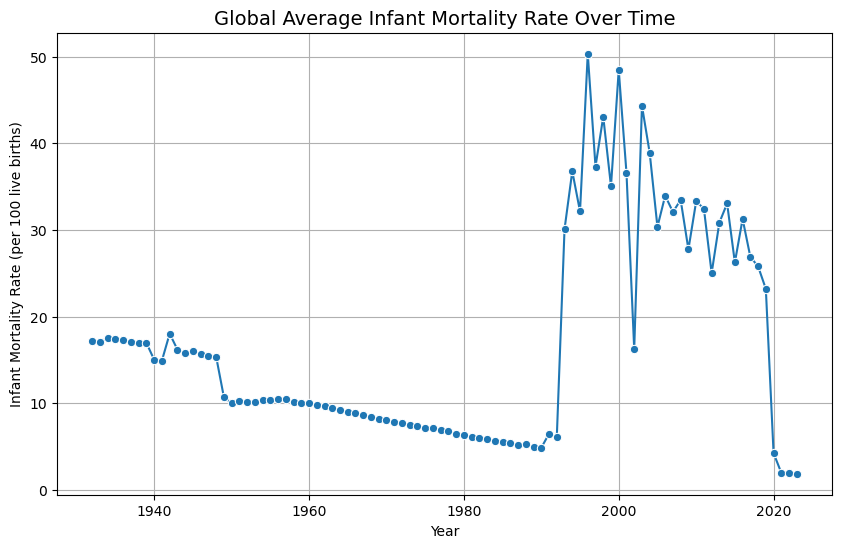

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global average infant mortality rate over time
global_trend = df_infant_data.groupby('year')['infant_mortality_rate'].mean()

plt.figure(figsize=(10,6))
sns.lineplot(x=global_trend.index, y=global_trend.values, marker="o")
plt.title("Global Average Infant Mortality Rate Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Infant Mortality Rate (per 100 live births)")
plt.grid(True)
plt.show()

### 2. Line Chart (Multiple) – Compare WHO vs OWID global trend

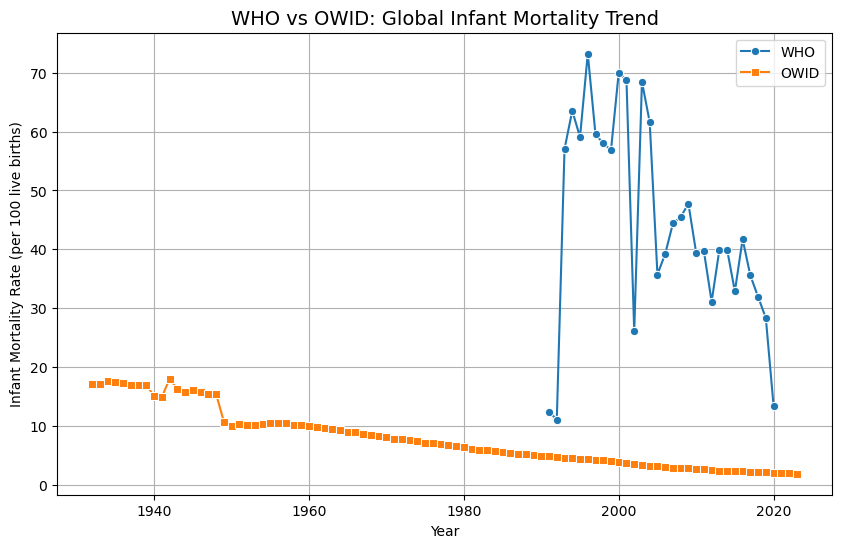

In [16]:
# Separate WHO and OWID data
who_trend = df_infant_data[df_infant_data['source']=="WHO"].groupby('year')['infant_mortality_rate'].mean()
owid_trend = df_infant_data[df_infant_data['source']=="OWID"].groupby('year')['infant_mortality_rate'].mean()

plt.figure(figsize=(10,6))
sns.lineplot(x=who_trend.index, y=who_trend.values, label="WHO", marker="o")
sns.lineplot(x=owid_trend.index, y=owid_trend.values, label="OWID", marker="s")

plt.title("WHO vs OWID: Global Infant Mortality Trend", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Infant Mortality Rate (per 100 live births)")
plt.legend()
plt.grid(True)
plt.show()

### 3. Bar Chart – Average infant mortality by decade

C:\Users\hp\AppData\Local\Temp\ipykernel_8640\3597992820.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_trend.index.astype(str), y=decade_trend.values, palette="viridis")


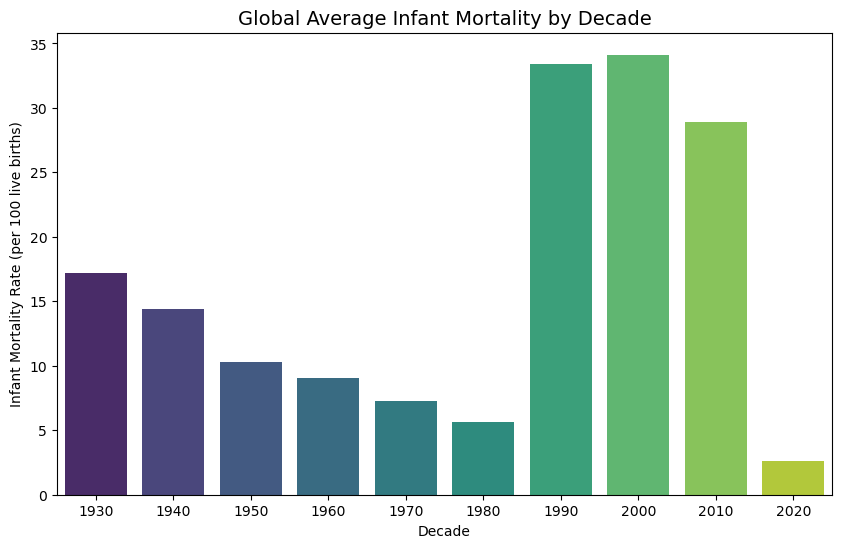

In [17]:
# Create decade column
df_infant_data['decade'] = (df_infant_data['year'] // 10) * 10

# Calculate global average by decade
decade_trend = df_infant_data.groupby('decade')['infant_mortality_rate'].mean()

plt.figure(figsize=(10,6))
sns.barplot(x=decade_trend.index.astype(str), y=decade_trend.values, palette="viridis")

plt.title("Global Average Infant Mortality by Decade", fontsize=14)
plt.xlabel("Decade")
plt.ylabel("Infant Mortality Rate (per 100 live births)")
plt.show()

### Filter dataset for (2000–2024)
We restrict the dataset to the years 2000–2024 for meaningful modern trend analysis.

In [25]:
# Restrict analysis to years 2000–2024

df_infant_data = df_infant_data[(df_infant_data['year'] >= 2000) & (df_infant_data['year'] <= 2024)]
print(df_infant_data['year'].min(), df_infant_data['year'].max())

# Check duplicates
print("Duplicate rows:", df_infant_data.duplicated().sum())

# Drop duplicates
df_infant_data = df_infant_data.drop_duplicates()

# Confirm
print("Shape after removing duplicates:", df_infant_data.shape)

2000 2023
Duplicate rows: 3457
Shape after removing duplicates: (13965, 5)


### 4. Line Chart – Global average infant mortality rate (2000–2024)

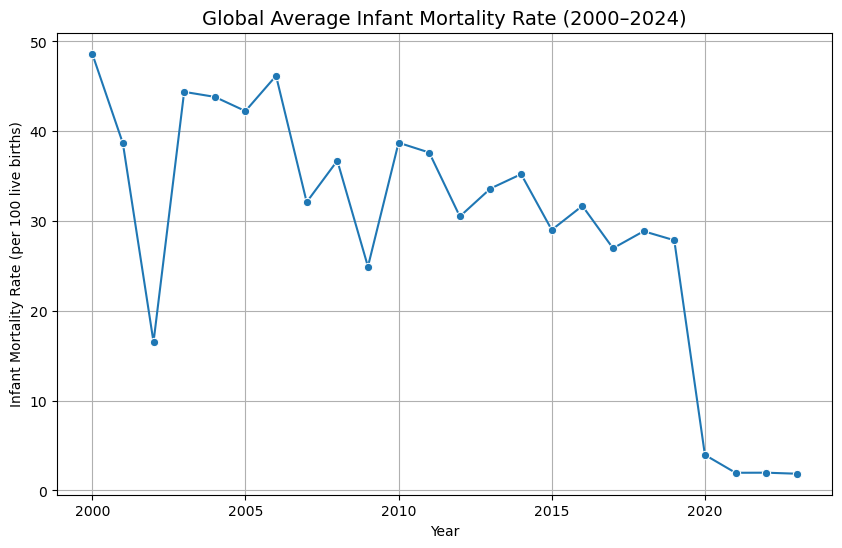

In [26]:
global_trend = df_infant_data.groupby('year')['infant_mortality_rate'].mean()

plt.figure(figsize=(10,6))
sns.lineplot(x=global_trend.index, y=global_trend.values, marker="o")
plt.title("Global Average Infant Mortality Rate (2000–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Infant Mortality Rate (per 100 live births)")
plt.grid(True)
plt.show()

### 5. Line Chart (Multiple) – WHO vs OWID (2000–2024)

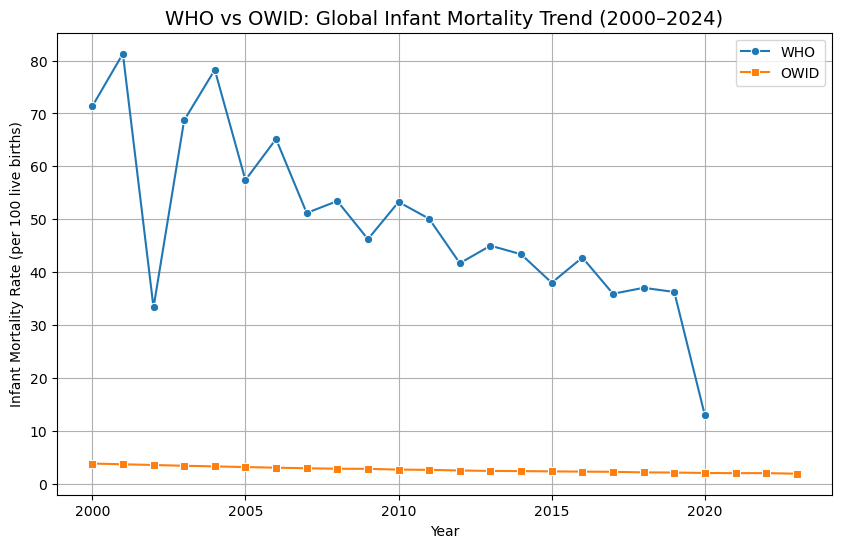

In [27]:
who_trend = df_infant_data[df_infant_data['source']=="WHO"].groupby('year')['infant_mortality_rate'].mean()
owid_trend = df_infant_data[df_infant_data['source']=="OWID"].groupby('year')['infant_mortality_rate'].mean()

plt.figure(figsize=(10,6))
sns.lineplot(x=who_trend.index, y=who_trend.values, label="WHO", marker="o")
sns.lineplot(x=owid_trend.index, y=owid_trend.values, label="OWID", marker="s")

plt.title("WHO vs OWID: Global Infant Mortality Trend (2000–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Infant Mortality Rate (per 100 live births)")
plt.legend()
plt.grid(True)
plt.show()

### 6. Bar Chart – Average by decade (2000s, 2010s, 2020s)

C:\Users\hp\AppData\Local\Temp\ipykernel_18976\1047730583.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




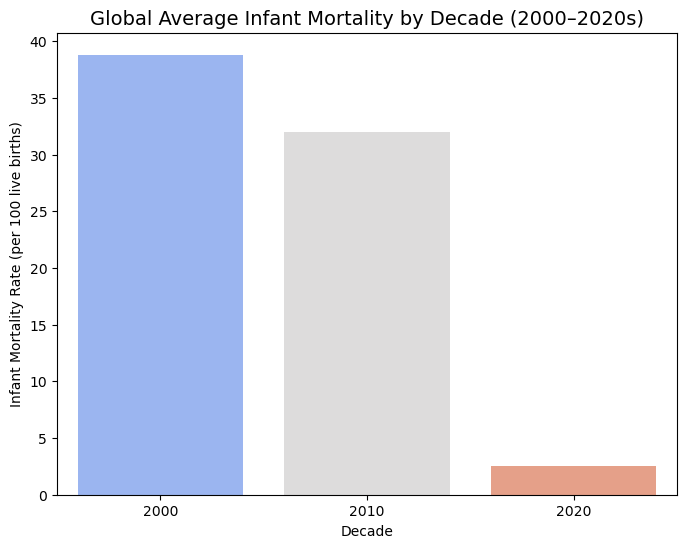

In [28]:
df_infant_data['decade'] = (df_infant_data['year'] // 10) * 10
decade_trend = df_infant_data.groupby('decade')['infant_mortality_rate'].mean()

plt.figure(figsize=(8,6))
sns.barplot(x=decade_trend.index.astype(str), y=decade_trend.values, palette="coolwarm")

plt.title("Global Average Infant Mortality by Decade (2000–2020s)", fontsize=14)
plt.xlabel("Decade")
plt.ylabel("Infant Mortality Rate (per 100 live births)")
plt.show()

### 7. Top 10 & Bottom 10 Countries in Latest Year

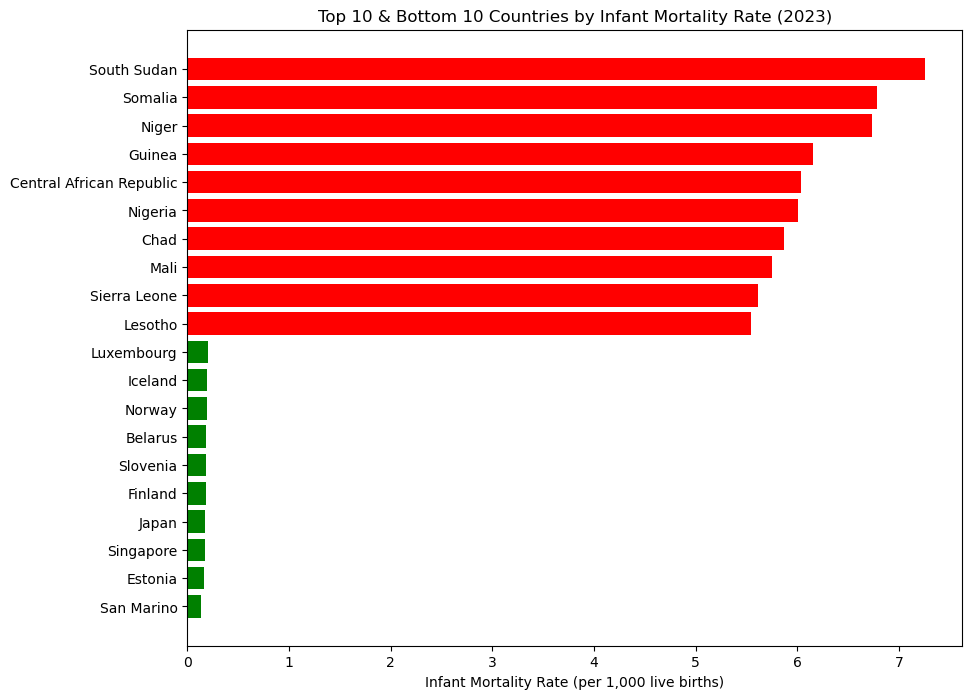

In [29]:
# Assuming your dataframe is already loaded as df_infant_data

# Filter only years between 2000–2024 (as per your requirement)
df_infant_data = df_infant_data[(df_infant_data['year'] >= 2000) & (df_infant_data['year'] <= 2024)]

# Find latest available year in dataset
latest_year = df_infant_data['year'].max()
df_latest = df_infant_data[df_infant_data['year'] == latest_year]

# Sort by infant mortality rate
df_sorted = df_latest.sort_values(by='infant_mortality_rate', ascending=False)

# Top 10 (highest mortality rates)
top_10 = df_sorted.head(10)

# Bottom 10 (lowest mortality rates)
bottom_10 = df_sorted.tail(10)

# Combine for plotting
combined = pd.concat([top_10, bottom_10])

# Plot Horizontal Bar Chart
plt.figure(figsize=(10, 8))
plt.barh(combined['country_name'], combined['infant_mortality_rate'], color=['red' if x in top_10['country_name'].values else 'green' for x in combined['country_name']])
plt.xlabel('Infant Mortality Rate (per 1,000 live births)')
plt.title(f'Top 10 & Bottom 10 Countries by Infant Mortality Rate ({latest_year})')
plt.gca().invert_yaxis()  # Highest at top
plt.show()


### 8. Global Average Infant Mortality Rate Over Time

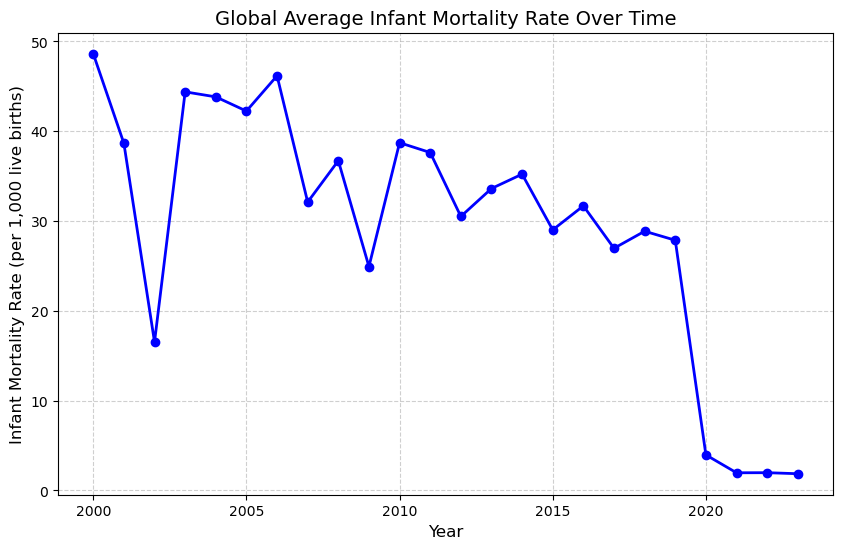

In [29]:
import matplotlib.pyplot as plt

# Calculate global average per year
global_trend = df_infant_data.groupby("year")["infant_mortality_rate"].mean()

plt.figure(figsize=(10,6))
plt.plot(global_trend.index, global_trend.values, marker="o", color="blue", linewidth=2)

plt.title("Global Average Infant Mortality Rate Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Infant Mortality Rate (per 1,000 live births)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### 9. Country-Level Trends (Selected Countries)

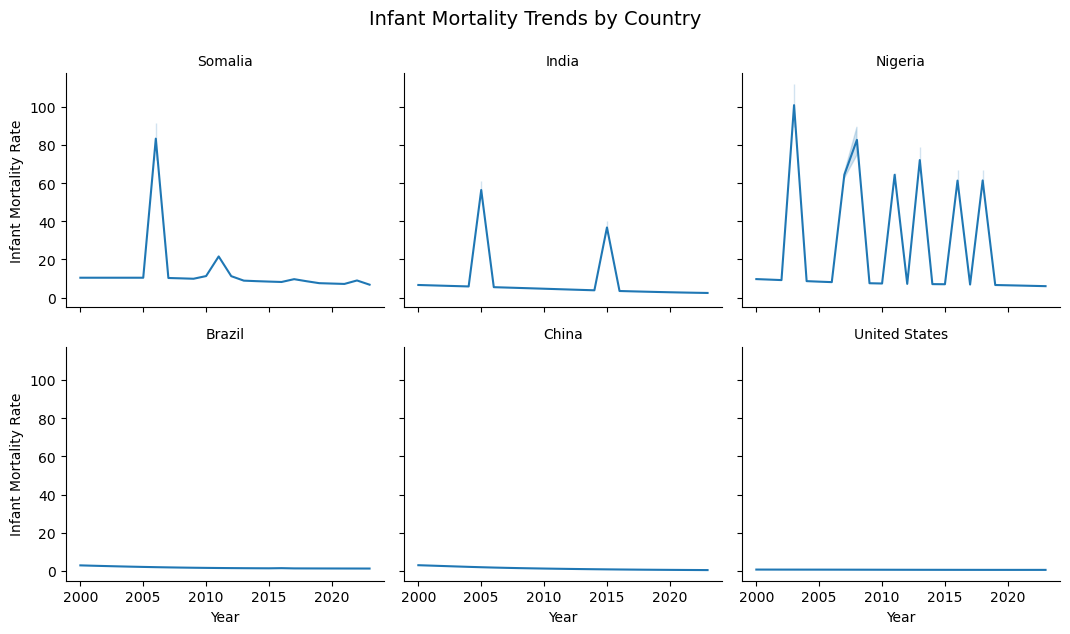

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# pick 6–8 representative countries
selected_countries = ["India", "Nigeria", "United States", "Brazil", "China", "Somalia"]

df_selected = df_infant_data[df_infant_data["country_name"].isin(selected_countries)]

g = sns.relplot(
    data=df_selected,
    x="year", y="infant_mortality_rate",
    kind="line",
    col="country_name", col_wrap=3,  # 3 charts per row
    height=3, aspect=1.2
)

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Infant Mortality Rate")
plt.suptitle("Infant Mortality Trends by Country", y=1.05, fontsize=14)
plt.show()
